In [39]:
exp_save_path = r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper\results\(n_train)1000__(B_RF)1000__(B_1)200__(n_sim)1000__(seed)42__4kovariates\121.90058'
#exp_save_path = r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper\results\(n_train)1000__(B_RF)1000__(B_1)200__(n_sim)1000__(seed)42__4kovariates_higherS(tau)\109.90058'

collage_name = 'figure3_morris_low_S.png'

xlim1 = [-99,1]
xlim2 = [-99,0.8]

#### setting

In [40]:
import pandas as pd
import json
import numpy as np 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
# erstelle verzeichnis, falls nicht vorhanden /help_figures
if not os.path.exists('help_figures'):
    os.makedirs('help_figures')

with open(exp_save_path + '/setting.json') as f:
    exp_settings = json.load(f)
S_t = exp_settings["true_survival_probability[1,3,5]"]

# lade results
results1 = pd.read_csv(exp_save_path + f"/results1__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][0]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][0]}.csv")
results3 = pd.read_csv(exp_save_path + f"/results3__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][1]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][1]}.csv")
results5 = pd.read_csv(exp_save_path + f"/results5__(zero_weights){exp_settings['portion_zero_weights_train[1,3,5]'][2]}__(seen_events){exp_settings['portion_seen_events_train[1,3,5]'][2]}.csv")
x_pred = exp_settings['X_pred_point']

#### help figures

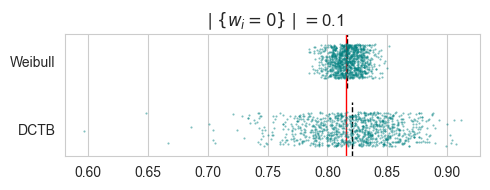

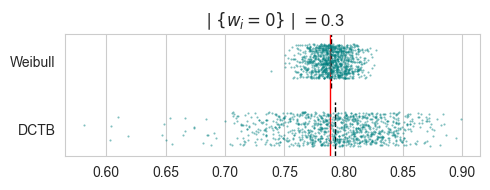

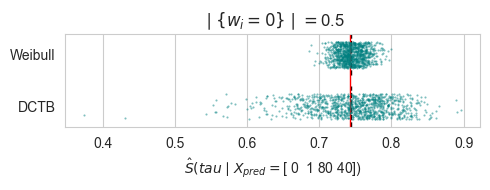

In [41]:
def plot_results(results1, S_t, prop_weights, xlim1):
    n = results1['wb_pred'].shape[0]  
    preds_wb  = results1['wb_pred']  
    preds_dctb = results1['rf_pred'] 

    df = pd.DataFrame({
        "value":  np.concatenate([preds_wb, preds_dctb]),
        "method": (["Weibull"] * n) 
                + (["DCTB"]     * n)})
    method_order = [ "DCTB","Weibull"]

    # Plot erstellen
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(5, 2))
    sns.stripplot(data=df,x="value",y="method",order=method_order,
                jitter=0.25,alpha=0.5,color="teal",size=1.5,ax=ax)

    # Linien 
    for i, m in enumerate(method_order):
        mean_val = df.loc[df["method"] == m, "value"].mean()
        ax.vlines( x=mean_val,ymin=i - 0.4,ymax=i + 0.4,color="black",linestyle="--",linewidth=1,alpha= 1)
    if prop_weights == 1:
        aa = 0
    elif prop_weights == 3:
        aa = 1
    elif prop_weights == 5: 
        aa = 2
            
    ax.axvline(x=S_t[aa], color="red", linestyle="-", linewidth=1)

    # Achsen und Layout
    ax.set_ylim(-0.4, 1.4)  # Werte anpassen, um den Abstand zu steuern
    #plt.xlim(xlim1)
    if prop_weights == 5:
        plt.xlabel(r"$\hat{S}(tau\mid X_{pred}=$"+x_pred+')')
    else:
        plt.xlabel("")
    #plt.xlabel(r"$\hat{S}(tau\mid X_{pred}=[$"+x_pred+'] )')
    plt.ylabel("")
    plt.title(r"$\mid \{w_i = 0\} \mid =$"+str(prop_weights/10))
    plt.tight_layout()
    if not os.path.exists('help_figures'):
        os.makedirs('help_figures')
    plt.savefig("./help_figures/preds"+str(prop_weights)+".png", dpi=300)

plot_results(results1, S_t, 1,xlim1)
plot_results(results3, S_t, 3,xlim1)
plot_results(results5, S_t, 5,xlim1)

In [42]:
u[:3], o[:3], S_t[0]

(0    0.851888
 1    0.856390
 2    0.839566
 dtype: float64,
 0    0.950790
 1    1.000248
 2    0.952658
 dtype: float64,
 0.8157739370157204)

In [43]:
def coverage_prop(ijk_std_estimate, S_dach, S):

    u = S_dach - 1.96 * ijk_std_estimate
    o = S_dach + 1.96 * ijk_std_estimate

    prop = np.sum((u <= S) & (o >= S)) / len(u)
    return prop.round(2)
coverage_prop(ijk_u_butt, S_dach, S_t[0])


0.24

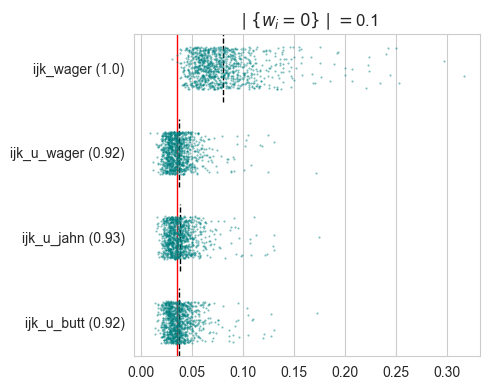

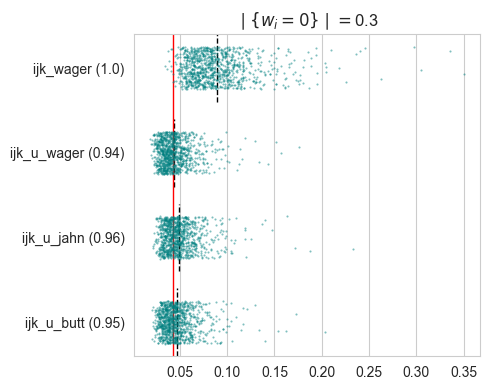

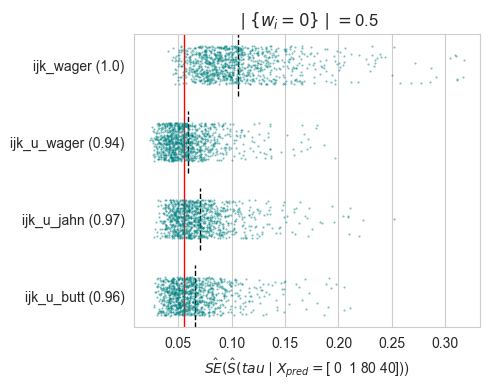

In [44]:
def save_var(results1,prop_weights,S_t, xlim2):

    n = results1['wb_pred'].shape[0]  
    ijk_u_butt  = results1['ijk_u_butt_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
    ijk_u_jahn = results1['ijk_u_jahn_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
    ijk_u_wager  =results1['ijk_u_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)
    ijk_wager = results1['ijk_wager_var'].apply(lambda x: np.sqrt(x) if x >= 0 else 0)

    if prop_weights == 1:
        coverage_prop_u_butt = coverage_prop(ijk_u_butt, results1['rf_pred'], S_t[0])
        coverage_prop_u_jahn = coverage_prop(ijk_u_jahn, results1['rf_pred'], S_t[0])
        coverage_prop_u_wager = coverage_prop(ijk_u_wager, results1['rf_pred'], S_t[0])
        coverage_prop_wager = coverage_prop(ijk_wager, results1['rf_pred'], S_t[0])
    elif prop_weights == 3:
        coverage_prop_u_butt = coverage_prop(ijk_u_butt, results1['rf_pred'], S_t[1])
        coverage_prop_u_jahn = coverage_prop(ijk_u_jahn, results1['rf_pred'], S_t[1])
        coverage_prop_u_wager = coverage_prop(ijk_u_wager, results1['rf_pred'], S_t[1])
        coverage_prop_wager = coverage_prop(ijk_wager, results1['rf_pred'], S_t[1])
    elif prop_weights == 5:
        coverage_prop_u_butt = coverage_prop(ijk_u_butt, results1['rf_pred'], S_t[2])
        coverage_prop_u_jahn = coverage_prop(ijk_u_jahn, results1['rf_pred'], S_t[2])
        coverage_prop_u_wager = coverage_prop(ijk_u_wager, results1['rf_pred'], S_t[2])
        coverage_prop_wager = coverage_prop(ijk_wager, results1['rf_pred'], S_t[2])

    df = pd.DataFrame({
        "value":  np.concatenate([ijk_u_butt, ijk_u_jahn, ijk_u_wager, ijk_wager]),
        "method": (['ijk_u_butt'+' ('+str(coverage_prop_u_butt)+str(')')] * n)
                + (['ijk_u_jahn'+' ('+str(coverage_prop_u_jahn)+str(')')]     * n)
                + (['ijk_u_wager'+' ('+str(coverage_prop_u_wager)+str(')')]         * n)
                + (['ijk_wager'+' ('+str(coverage_prop_wager)+str(')')]        * n)               })

    method_order = ["ijk_u_butt"+' ('+str(coverage_prop_u_butt)+str(')'), 
                    "ijk_u_jahn"+' ('+str(coverage_prop_u_jahn)+str(')'), 
                    "ijk_u_wager"+' ('+str(coverage_prop_u_wager)+str(')'), 
                    "ijk_wager"+' ('+str(coverage_prop_wager)+str(')')]

    # Plot erstellen
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(5, 4))

    sns.stripplot(data=df,x="value",y="method",order=method_order,
                jitter=0.25,alpha=0.5,color="teal",size=1.5,ax=ax)

    # Linien
    for i, m in enumerate(method_order):
        mean_val = df.loc[df["method"] == m, "value"].mean()
        ax.vlines(x=mean_val,ymin=i - 0.4,ymax=i + 0.4,color="black",
            linestyle="--",linewidth=1,alpha=1)
    ax.axvline(x=results1['rf_pred'].std(ddof=1), color="red", linestyle="-", linewidth=1)

    # Layout 
    ax.set_ylim(-0.4, 3.4)  # Platz für vier Methoden
    #plt.xlabel(r"$\hat{SE}( \hat{S}(tau\mid X_{pred}=[$"+x_pred+']) )')
    plt.title(r"$\mid \{w_i = 0\} \mid =$"+str(prop_weights/10))
    if prop_weights == 5:
        plt.xlabel(r"$\hat{SE}(\hat{S}(tau\mid X_{pred}=$"+x_pred+'))')
    else:
        plt.xlabel("")

    #plt.xlim(xlim2)
    plt.ylabel("")
    plt.tight_layout()
    if not os.path.exists('help_figures'):
        os.makedirs('help_figures')
    plt.savefig("./help_figures/vars"+str(prop_weights)+".png", dpi=300)

save_var(results1,1,S_t,xlim2)
save_var(results3,3,S_t,xlim2)
save_var(results5,5,S_t,xlim2)



#### erstelle figure 3 morris

In [45]:
import os
from PIL import Image

# Pfad zum Ordner mit den Bildern
pp = r'C:\\Users\\rehan\\meine_Repos\\Masterarbeit\\Paper\\help_figures'

image_files = [
    "preds1.png", "vars1.png",
    "preds3.png", "vars3.png",
    "preds5.png", "vars5.png"
]

# Lade die Bilder
images = [Image.open(os.path.join(pp, f)) for f in image_files]

# Prüfe, ob alle Bilder erfolgreich geladen wurden
if len(images) != 6:
    raise ValueError("Es konnten nicht alle 6 Bilder geladen werden. Überprüfe die Dateinamen und den Pfad.")

# Ermittle die maximale Breite und Höhe der Bilder
widths, heights = zip(*(img.size for img in images))
max_width = max(widths)
max_height = max(heights)

# Neues Bild mit 2 Spalten und 3 Zeilen erstellen
new_width = 2 * max_width
new_height = 3 * max_height
new_img = Image.new("RGB", (new_width, new_height), "white")  # Hintergrund auf weiß setzen

# Positionen für die 6 Bilder
positions = [
    (0, 0), (max_width, 0),           # Erste Zeile: preds1, vars1
    (0, max_height), (max_width, max_height),  # Zweite Zeile: preds3, vars3
    (0, 2 * max_height), (max_width, 2 * max_height)  # Dritte Zeile: preds5, vars5
]

# Bilder einfügen
for pos, img in zip(positions, images):
    new_img.paste(img, pos)

# Speichere das Ergebnis
output_path = os.path.join(pp, collage_name)
new_img.save(output_path)
print(f"Collage wurde erfolgreich unter {output_path} gespeichert.")

# lösch die image files 
for f in image_files:
    os.remove(os.path.join(pp, f))

Collage wurde erfolgreich unter C:\\Users\\rehan\\meine_Repos\\Masterarbeit\\Paper\\help_figures\figure3_morris_low_S.png gespeichert.
